In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import (proportions_ztest, proportion_confint,
                                          confint_proportions_2indep, proportion_effectsize)
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt

print("environment ready")

environment ready


In [2]:
raw = pd.read_csv('landing_page_ab_test_dataset.csv')
raw['Visit_Date'] = pd.to_datetime(raw['Visit_Date'])
raw['conv']   = (raw['Converted'] == 'Yes').astype(int)
raw['bounce'] = (raw['Bounce']   == 'Yes').astype(int)

print("Shape:", raw.shape)
print("Nulls:", raw.isnull().sum().sum())
print("Duplicate Visitor_IDs:", raw['Visitor_ID'].duplicated().sum())
print("Date range:", raw['Visit_Date'].min().date(), "→", raw['Visit_Date'].max().date())
print("Overall conversion (row level):", f"{raw['conv'].mean():.2%}")\
    

Shape: (8435, 10)
Nulls: 0
Duplicate Visitor_IDs: 235
Date range: 2026-05-18 → 2026-06-28
Overall conversion (row level): 3.65%


In [3]:
cross_arm = (raw.groupby('Visitor_ID')['Group'].nunique() > 1).sum()
visits_per = raw.groupby('Visitor_ID').size()
print("Visitors appearing in BOTH arms:", cross_arm)
print("Visitors with repeat visits:", (visits_per > 1).sum(), "| max visits:", visits_per.max())

Visitors appearing in BOTH arms: 0
Visitors with repeat visits: 235 | max visits: 2


In [4]:
v = (raw.sort_values('Visit_Date')
        .groupby('Visitor_ID')
        .agg(Group=('Group', 'first'),
             first_visit=('Visit_Date', 'first'),
             visits=('Visitor_ID', 'size'),
             Traffic_Source=('Traffic_Source', 'first'),
             Device=('Device', 'first'),
             total_time=('Time_On_Page', 'sum'),
             converted=('conv', 'max'),
             bounced=('bounce', 'min'))
        .reset_index())

print("Visitor-level table:", v.shape)
print(v['Group'].value_counts().to_dict())

Visitor-level table: (8200, 9)
{'Control': 4120, 'Treatment': 4080}


In [5]:
pw = NormalIndPower()
es_mde = proportion_effectsize(0.04, 0.03)        # detect 3% -> 4% (+1pp)
n_required = pw.solve_power(effect_size=es_mde, alpha=0.05, power=0.80,
                            alternative='two-sided')
actual_power = pw.solve_power(effect_size=es_mde, nobs1=4100, alpha=0.05,
                              alternative='two-sided')
print(f"Required per arm to detect +1pp at 3% baseline: {n_required:,.0f}")
print(f"Actual power at ~4,100/arm: {actual_power:.1%}")

Required per arm to detect +1pp at 3% baseline: 5,275
Actual power at ~4,100/arm: 69.5%


In [6]:
n_c = (v['Group']=='Control').sum(); n_t = (v['Group']=='Treatment').sum()
srm_stat, srm_p = stats.chisquare([n_c, n_t], f_exp=[len(v)/2, len(v)/2])
print(f"SRM: {n_c:,} vs {n_t:,} | p = {srm_p:.4f} "
      f"{'PASS ✅' if srm_p > 0.001 else 'FAIL ❌ stop here'}")

for col in ['Traffic_Source', 'Device']:
    p_bal = stats.chi2_contingency(pd.crosstab(v['Group'], v[col])).pvalue
    print(f"{col:15s} balance p = {p_bal:.4f} {'PASS ✅' if p_bal > 0.05 else '⚠️'}")

SRM: 4,120 vs 4,080 | p = 0.6587 PASS ✅
Traffic_Source  balance p = 0.4995 PASS ✅
Device          balance p = 0.6723 PASS ✅


In [7]:
t = v[v['Group']=='Treatment']; c = v[v['Group']=='Control']
suc = np.array([t['converted'].sum(), c['converted'].sum()])
nb  = np.array([len(t), len(c)])

z_stat, p_value = proportions_ztest(suc, nb)
p_t, p_c = suc / nb
lift = p_t - p_c
ci_lo, ci_hi = confint_proportions_2indep(suc[0], nb[0], suc[1], nb[1], method='wald')

print(f"Control:   {p_c:.4f}  ({suc[1]}/{nb[1]:,})")
print(f"Treatment: {p_t:.4f}  ({suc[0]}/{nb[0]:,})")
print(f"Lift: {lift*100:+.2f}pp | Relative: {lift/p_c:+.1%}")
print(f"z = {z_stat:.4f}, p = {p_value:.5f}")
print(f"95% CI: [{ci_lo*100:.2f}, {ci_hi*100:.2f}]pp")

# what the naive row-level analysis would have said (for the report appendix)
suc_r = np.array([raw[raw.Group=='Treatment']['conv'].sum(), raw[raw.Group=='Control']['conv'].sum()])
nb_r  = np.array([(raw.Group=='Treatment').sum(), (raw.Group=='Control').sum()])
print(f"\n[Naive row-level would give: {suc_r[0]/nb_r[0]:.4f} vs {suc_r[1]/nb_r[1]:.4f}, "
      f"p = {proportions_ztest(suc_r, nb_r)[1]:.5f}]")

Control:   0.0308  (127/4,120)
Treatment: 0.0444  (181/4,080)
Lift: +1.35pp | Relative: +43.9%
z = 3.2237, p = 0.00127
95% CI: [0.53, 2.18]pp

[Naive row-level would give: 0.0431 vs 0.0300, p = 0.00137]


In [8]:
# Bounce (proportion -> z-test)
suc_b = np.array([t['bounced'].sum(), c['bounced'].sum()])
z_b, p_b = proportions_ztest(suc_b, nb)
print(f"Bounce: Ctrl {suc_b[1]/nb[1]:.1%} vs Trt {suc_b[0]/nb[0]:.1%} | z = {z_b:.2f}, p = {p_b:.6f}")

# Time on page (skewed -> Mann-Whitney)
print("Time-on-page skew:", stats.skew(v['total_time']).round(2))
mw = stats.mannwhitneyu(t['total_time'], c['total_time'])
print(f"Time:   Ctrl median {c['total_time'].median():.1f}s vs Trt {t['total_time'].median():.1f}s "
      f"| Mann-Whitney p = {mw.pvalue:.6f}")

Bounce: Ctrl 64.6% vs Trt 57.9% | z = -6.18, p = 0.000000
Time-on-page skew: 6.25
Time:   Ctrl median 16.9s vs Trt 20.0s | Mann-Whitney p = 0.000000


In [9]:
rows = []
for col in ['Device', 'Traffic_Source']:
    for val in sorted(v[col].unique()):
        s = v[v[col]==val]
        st_, sc_ = s[s.Group=='Treatment'], s[s.Group=='Control']
        su = np.array([st_['converted'].sum(), sc_['converted'].sum()])
        nn = np.array([len(st_), len(sc_)])
        z_, p_ = proportions_ztest(su, nn)
        rows.append({'segment': val, 'n': nn.sum(),
                     'lift_pp': round((su[0]/nn[0]-su[1]/nn[1])*100, 2),
                     'p': round(p_, 4), 'sig_bonf': p_ < 0.05/8})
pd.DataFrame(rows)

,segment,n,lift_pp,p,sig_bonf
0,Desktop,4431,1.55,0.0126,False
1,Mobile,3212,0.77,0.1718,False
2,Tablet,557,2.92,0.1020,False
3,direct,1387,3.15,0.0094,False
4,organic_search,2863,0.34,0.6270,False
5,paid_search,2126,2.14,0.0129,False
6,referral,761,0.69,0.6367,False
7,social_media,1063,0.44,0.4991,False


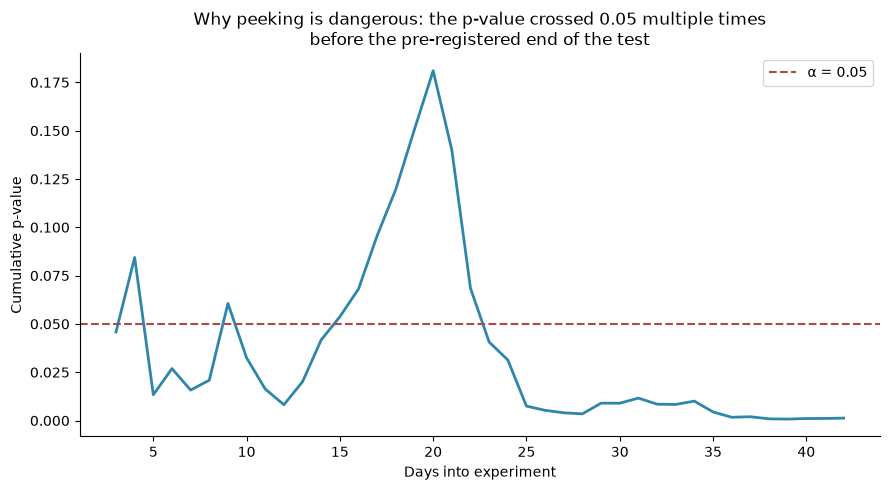

 day       date    n      p
   7 2026-05-24 1197 0.0158
  14 2026-05-31 2654 0.0418
  21 2026-06-07 4004 0.1400
  28 2026-06-14 5338 0.0035
  35 2026-06-21 6737 0.0045
  42 2026-06-28 8200 0.0013


C:\Users\USER\AppData\Local\Temp\ipykernel_14948\2729871376.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(tr[tr['day'].isin([7,14,21,28,35,42])].round(4).to_string(index=False))


In [10]:
days = sorted(v['first_visit'].unique())
trace = []
for i, d in enumerate(days):
    sub = v[v['first_visit'] <= d]
    st_, sc_ = sub[sub.Group=='Treatment'], sub[sub.Group=='Control']
    su = np.array([st_['converted'].sum(), sc_['converted'].sum()])
    nn = np.array([len(st_), len(sc_)])
    if min(su) >= 5:
        trace.append({'day': i+1, 'date': d, 'n': nn.sum(),
                      'p': proportions_ztest(su, nn)[1]})
tr = pd.DataFrame(trace)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(tr['day'], tr['p'], color='#2E86AB', lw=2)
ax.axhline(0.05, color='#B04A4A', ls='--', lw=1.5, label='α = 0.05')
ax.set_xlabel('Days into experiment'); ax.set_ylabel('Cumulative p-value')
ax.set_title('Why peeking is dangerous: the p-value crossed 0.05 multiple times\n'
             'before the pre-registered end of the test')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print(tr[tr['day'].isin([7,14,21,28,35,42])].round(4).to_string(index=False))

In [11]:
annual_visitors = 71_000
value_per_conv  = 150

for label, pp in [('Conservative (CI low)', ci_lo), ('Point estimate', lift),
                  ('Optimistic (CI high)', ci_hi)]:
    extra = pp * annual_visitors
    print(f"{label:22s}: {pp*100:+.2f}pp → {extra:,.0f} extra signups/yr → ${extra*value_per_conv:,.0f}/yr")

Conservative (CI low) : +0.53pp → 377 extra signups/yr → $56,500/yr
Point estimate        : +1.35pp → 961 extra signups/yr → $144,174/yr
Optimistic (CI high)  : +2.18pp → 1,546 extra signups/yr → $231,849/yr


In [12]:
export = v.copy()
export['first_visit'] = export['first_visit'].dt.date
export.to_csv('landing_page_visitor_level.csv', index=False)

summary = pd.DataFrame([{
    'metric': 'Conversion', 'control': p_c, 'treatment': p_t,
    'lift_pp': lift*100, 'p_value': p_value,
    'ci_low_pp': ci_lo*100, 'ci_high_pp': ci_hi*100
}])
summary.to_csv('landing_page_test_summary.csv', index=False)
print("Exported: landing_page_visitor_level.csv (8,200 rows) + landing_page_test_summary.csv")

Exported: landing_page_visitor_level.csv (8,200 rows) + landing_page_test_summary.csv
